In [ ]:
pip install qiskit qiskit-aer matplotlib numpy


BELL STATE CIRCUIT
          ┌───┐┌─┐   
q_0: ─────┤ X ├┤M├───
     ┌───┐└─┬─┘└╥┘┌─┐
q_1: ┤ H ├──■───╫─┤M├
     └───┘      ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

BELL STATE RESULTS
00 count : 590
P(00)   : 0.4917
01 count : 0
P(01)   : 0.0000
10 count : 0
P(10)   : 0.0000
11 count : 610
P(11)   : 0.5083


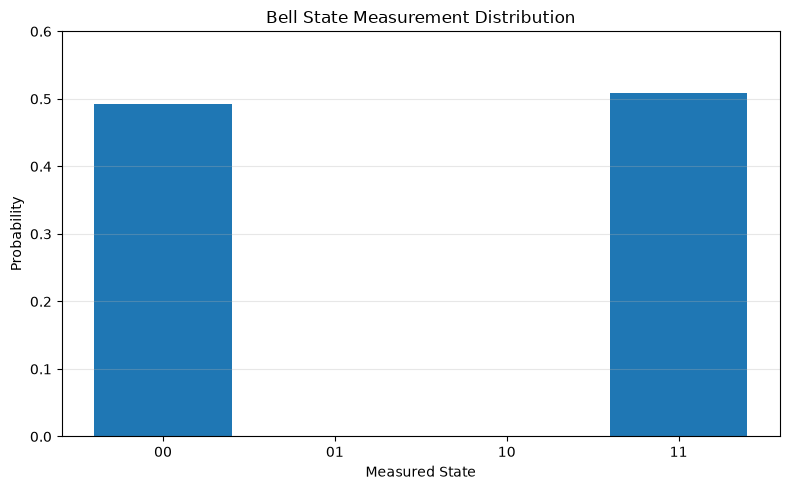

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

shots = 1200

qc = QuantumCircuit(2, 2)

qc.h(1)
qc.cx(1, 0)

qc.measure(0, 0)
qc.measure(1, 1)

print("\nBELL STATE CIRCUIT")
print("=" * 55)
print(qc.draw())

simulator = AerSimulator()
result = simulator.run(qc, shots=shots).result()
counts = result.get_counts()

print("\nBELL STATE RESULTS")
print("=" * 55)

for state in ["00", "01", "10", "11"]:
    count = counts.get(state, 0)
    probability = count / shots
    print(f"{state} count : {count}")
    print(f"P({state})   : {probability:.4f}")

states = ["00", "01", "10", "11"]
probabilities = [counts.get(state, 0) / shots for state in states]

plt.figure(figsize=(8, 5))
plt.bar(states, probabilities)
plt.xlabel("Measured State")
plt.ylabel("Probability")
plt.title("Bell State Measurement Distribution")
plt.ylim(0, 0.6)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()